# **Identifying Key Entities in Recipe Data**


**Business Objective**:
The goal of this project is to train a Named Entity Recognition (NER) model using Conditional Random Fields (CRF) to extract key entities from recipe data. The model will classify words into predefined categories such as ingredients, quantities and units, enabling the creation of a structured database of recipes and ingredients that can be used to power advanced features in recipe management systems, dietary tracking apps, or e-commerce platforms.

### **Data Description**
The given data is in JSON format, representing a **structured recipe ingredient list** with **Named Entity Recognition (NER) labels**. Below is a breakdown of the data fields:

```json
[
    {
        "input": "6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil",
        "pos": "quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient"
    },
    {
      "input": "2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida",
      "pos": "quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient"
    }
]


| **Key**  | **Description**  |
|----------|-----------------|
| `input`  | Contains a raw ingredient list from a recipe. |
| `pos`    | Represents the corresponding part-of-speech (POS) tags or NER labels, identifying quantities, ingredients, and units. |


## **1** Import libraries

#### **1.1** Installation of sklearn-crfsuite

sklearn-crfsuite is a Python wrapper for CRFsuite, a fast and efficient implementation of Conditional Random Fields (CRFs). It is designed to integrate seamlessly with scikit-learn for structured prediction tasks such as Named Entity Recognition (NER), Part-of-Speech (POS) tagging, and chunking.

In [1]:
# installation of sklearn_crfsuite
!pip install sklearn_crfsuite==0.5.0


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### **1.2** Import necessary libraries

In [2]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Import necessary libraries
import json  # For handling JSON data
import pandas as pd  # For data manipulation and analysis
import re  # For regular expressions (useful for text preprocessing)
import matplotlib.pyplot as plt  # For visualisation
import seaborn as sns  # For advanced data visualisation
import sklearn_crfsuite  # CRF (Conditional Random Fields) implementation for sequence modeling
import numpy as np  # For numerical computations
# Saving and loading machine learning models
import joblib
import random
import spacy
from IPython.display import display, Markdown # For displaying well-formatted output

from fractions import Fraction  # For handling fractional values in numerical data
# Importing tools for feature engineering and model training
from collections import Counter  # For counting occurrences of elements in a list
from sklearn.model_selection import train_test_split  # For splitting dataset into train and test sets
from sklearn_crfsuite import metrics  # For evaluating CRF models
from sklearn_crfsuite.metrics import flat_classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix

In [4]:
# Ensure pandas displays full content
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

## **2** Data Ingestion and Preparation

#### **2.1** *Read Recipe Data from Dataframe and prepare the data for analysis*
Read the data from JSON file, print first five rows and describe the dataframe

##### **2.1.1** **Define a *load_json_dataframe* function** 

Define a function that takes path of the ingredient_and_quantity.json file and reads it, convert it into dataframe - df and return it.

In [5]:
# define a function to load json file to a dataframe
def load_json_dataframe(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
        df = pd.DataFrame(data)
        return df

##### **2.1.2** **Execute the *load_json_dataframe* function** 

In [6]:
# read the json file by giving the file path and create a dataframe
file_path = 'ingredient_and_quantity.json'

# Function to load JSON data into a DataFrame
def load_json_dataframe(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return pd.DataFrame(data)

# Load the data
df = load_json_dataframe(file_path)

##### **2.1.3** **Describe the dataframe** 

Print first five rows of dataframe along with dimensions. Display the information of dataframe

In [7]:
# display first five rows of the dataframe - df
df.head()

,input,pos
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient quantity unit ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
4,1 tablespoon chana dal white urad 2 red chillies coriander seeds 3 inches ginger onion tomato Teaspoon mustard asafoetida sprig curry,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient unit ingredient


In [8]:
# print the dimensions of dataframe - df
df.shape

(285, 2)

In [9]:
# print the information of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   input   285 non-null    object
 1   pos     285 non-null    object
dtypes: object(2)
memory usage: 4.6+ KB


#### **2.2** *Recipe Data Manipulation*
Create derived metrics in dataframe and provide insights of the dataframe

##### **2.2.1** **Create input_tokens and pos_tokens columns by splitting the input and pos from the dataframe** 
Split the input and pos into input_tokens and pos_tokens in the dataframe and display it in the dataframe

In [10]:
# split the input and pos into input_tokens and pos_tokens in the dataframe
# Tokenize input
df['input_tokens'] = df['input'].apply(lambda x: x.split())
# Tokenize POS
df['pos_tokens'] = df['pos'].apply(lambda x: x.split())

In [11]:
# display first five rows of the dataframe - df
df.head()

,input,pos,input_tokens,pos_tokens
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, Onion, 3, tablespoon, Gram, flour, besan, 2, teaspoons, Turmeric, powder, Haldi, Red, Chilli, Cumin, seeds, Jeera, Coriander, Powder, Dhania, Amchur, Dry, Mango, Sunflower, Oil]","[quantity, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]"
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient,"[2-1/2, cups, rice, cooked, 3, tomatoes, teaspoons, BC, Belle, Bhat, powder, 1, teaspoon, chickpea, lentils, 1/2, cumin, seeds, white, urad, dal, mustard, green, chilli, dry, red, 2, cashew, or, peanuts, 1-1/2, tablespoon, oil, asafoetida]","[quantity, unit, ingredient, ingredient, quantity, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient]"
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient,"[1-1/2, cups, Rice, Vermicelli, Noodles, Thin, 1, Onion, sliced, 1/2, cup, Carrots, Gajjar, chopped, 1/3, Green, peas, Matar, 2, Chillies, 1/4, teaspoon, Asafoetida, hing, Mustard, seeds, White, Urad, Dal, Split, Ghee, sprig, Curry, leaves, Salt, Lemon, juice]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient]"
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient qua

##### **2.2.2** **Provide the length for input_tokens and pos_tokens and validate their length**

Create input_length and pos_length columns in the dataframe and validate both the lengths. Check for the rows that are unequal in input and pos length


In [12]:
# create input_length and pos_length columns for the input_tokens and pos-tokens
df['input_length'] = df['input_tokens'].apply(lambda x: len(x))
df['pos_length'] = df['pos_tokens'].apply(lambda x: len(x))

In [13]:
# check for the equality of input_length and pos_length in the dataframe
df['length_equal'] = df['input_length'] == df['pos_length']

print(f"Number of mismatched : {df[df['length_equal'] == False].shape[0]}")

Number of mismatched : 5


In [14]:
df[df['length_equal'] == False].index

Index([17, 27, 79, 164, 207], dtype='int64')

##### **2.2.3** **Define a unique_labels function and validate the labels in pos_tokens**

Define a unique_labels function which checks for all the unique pos labels in the recipe & execute it.


In [15]:
# Define a unique_labels function to checks for all the unique pos labels in the recipe & print it
def unique_labels(df):
    unique_labels = set()
    for pos in df['pos_tokens']:
        unique_labels.update(pos)
    return unique_labels

print(f"Unique Pos labels : {unique_labels(df)}")

Unique Pos labels : {'ingredient', 'quantity', 'unit'}


##### **2.2.3** **Provide the insights seen in the recipe data after validation**

Provide the indexes that requires cleaning and formatting in the dataframe

<font color = green>Index [17, 27, 79, 164, 207] contain inconsistent fraction formats, ambiguous ingredient naming, duplicate terms, and missing or misordered units, and therefore require cleaning and formatting before modeling</font> <br>


##### **2.2.4** **Drop the rows that have invalid data provided in previous cell**

In [16]:
# drop the irrelevant recipe data
irrelevant_indices = df[df['length_equal'] == False].index

df = df.drop(irrelevant_indices)
df.shape

(280, 7)

##### **2.2.5** **Update the input_length & pos_length in dataframe**

In [17]:
# update the input and pos length in input_length and pos_length
df['input_length']=df['input_tokens'].apply(lambda x:len(x))
df['pos_length']=df['pos_tokens'].apply(lambda x:len(x))

##### **2.2.6** **Validate the input_length and pos_length by checking unequal rows**

In [18]:
# validate the input length and pos length as input_length and pos_length
len(df[df['length_equal'] == False].index)

0

## **3** Train Validation Split (70 train - 30 val) 

#### **3.1** *Perform train and validation split ratio* 
Split the dataset with the help of input_tokens and pos_tokens and make a ratio of 70:30 split for training and validation datasets.

##### **3.1.1** **Split the dataset into train_df and val_df into 70:30 ratio**

In [19]:
# split the dataset into training and validation sets
train_df, val_df = train_test_split(df, test_size=0.3, random_state=42)

##### **3.1.2** **Print the first five rows of train_df and val_df**

In [20]:
# print the first five rows of train_df
train_df.head()

,input,pos,input_tokens,pos_tokens,input_length,pos_length,length_equal
179,250 grams Okra Oil 1 Onion finely chopped Tomato Grated teaspoon Ginger 2 Garlic Finely 1/2 Cumin seeds 1/4 Teaspoon asafoetida cup cottage cheese pinched coriander powder mango red chilli turmeric,quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient unit ingredient quantity ingredient ingredient quantity ingredient ingredient quantity unit ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[250, grams, Okra, Oil, 1, Onion, finely, chopped, Tomato, Grated, teaspoon, Ginger, 2, Garlic, Finely, 1/2, Cumin, seeds, 1/4, Teaspoon, asafoetida, cup, cottage, cheese, pinched, coriander, powder, mango, red, chilli, turmeric]","[quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",31,31,True
57,200 grams Paneer Homemade Cottage Cheese 2 Potato Aloo Bay leaf tej patta Dry Red Chilli 1 tablespoon Panch Phoran Masala roasted and powdered Tomato big sized teaspoon Turmeric powder Haldi Cumin seeds Jeera Ginger grated Salt 1/2 Sugar Sunflower Oil,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient,"[200, grams, Paneer, Homemade, Cottage, Cheese, 2, Potato, Aloo, Bay, leaf, tej, patta, Dry, Red, Chilli, 1, tablespoon, Panch, Phoran, Masala, roasted, and, powdered, Tomato, big, sized, teaspoon, Turmeric, powder, Haldi, Cumin, seeds, Jeera, Ginger, grated, Salt, 1/2, Sugar, Sunflower, Oil]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient]",41,41,True
112,500 grams Cabbage Patta Gobi Muttaikose 1 teaspoon Mustard seeds 1-1/2 White Urad Dal Split sprig Curry leaves Green Chilli 1/4 cup Fresh coconut Salt,quantity unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient,"[500, grams, Cabbage, Patta, Gobi, Muttaikose, 1, teaspoon, Mustard, seeds, 1-1/2, White, Urad, Dal, Split, sprig, Curry, leaves, Green, Chilli, 1/4, cup, Fresh, coconut, Salt]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient]",25,25,True
218,500 grams Fresh Figs 1/4 cup Lemon juice 1 teaspoon zest 2 Red Chilli flakes 1/2 Honey Brown Sugar (Demerara Sugar),quantity unit ingredient ingredient quantity unit ingredient ingredient quantity unit ingredient quantity ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient,"[500, grams, Fresh, Figs, 1/4, cup, Lemon, juice, 1, teaspoon, zest, 2, Red, Chilli, flakes, 1/2, Honey, Brown, Sugar, (Demerara, Sugar)]","[quantity, unit, ingredient, ingredient, quantity, unit,

In [21]:
# print the first five rows of the val_df
val_df.head()

,input,pos,input_tokens,pos_tokens,input_length,pos_length,length_equal
35,1 cup Ada 2 liter Milk 3/4 Sugar tablespoon Ghee 1/2 teaspoon Cardamom Powder Elaichi,quantity unit ingredient quantity unit ingredient quantity ingredient unit ingredient quantity unit ingredient ingredient ingredient,"[1, cup, Ada, 2, liter, Milk, 3/4, Sugar, tablespoon, Ghee, 1/2, teaspoon, Cardamom, Powder, Elaichi]","[quantity, unit, ingredient, quantity, unit, ingredient, quantity, ingredient, unit, ingredient, quantity, unit, ingredient, ingredient, ingredient]",15,15,True
111,1 Carrot Gajjar chopped 7 Potatoes Aloo 2 cups Cauliflower gobi cut to small florets Onion tablespoon Ginger Garlic Paste Salt teaspoons Sunflower Oil 1/2 cup Fresh coconut grated teaspoon Whole Black Peppercorns Green Chillies Fennel seeds Saunf Poppy 6 Cashew nuts inch Cinnamon Stick Dalchini Star anise 3 Cloves Laung Cardamom Elaichi Pods/Seeds Cumin Jeera,quantity ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[1, Carrot, Gajjar, chopped, 7, Potatoes, Aloo, 2, cups, Cauliflower, gobi, cut, to, small, florets, Onion, tablespoon, Ginger, Garlic, Paste, Salt, teaspoons, Sunflower, Oil, 1/2, cup, Fresh, coconut, grated, teaspoon, Whole, Black, Peppercorns, Green, Chillies, Fennel, seeds, Saunf, Poppy, 6, Cashew, nuts, inch, Cinnamon, Stick, Dalchini, Star, anise, 3, Cloves, Laung, Cardamom, Elaichi, Pods/Seeds, Cumin, Jeera]","[quantity, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",56,56,True
245,1 tablespoon Sunflower Oil 3 Potato Aloo Ginger paste Green Chilli chopped 1-1/12 tablespoons Sesame seeds Til teaspoon Red powder Cumin Jeera Coriander Powder Dhania 1/2 Garam masala 2 Sweet Chutney Date Tamarind Leaves few,quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient,"[1, tablespoon, Sunflower, Oil, 3, Potato, Aloo, Ginger, paste, Green, Chilli, chopped, 1-1/12, tablespoons, Sesame, seeds, Til, teaspoon, Red, powder, Cumin, Jeera, Coriander, Powder, Dhania, 1/2, Garam, masala, 2, Sweet, Chutney, Date, Tamarind, Leaves, few]","[quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",35,35,True
264,1 cup green peas gram flour 1/2 cheese tsp ginger 2 chillies turmeric powder cumin teaspoon salt oil,quantity unit ingredient ingredient ingredient ingredient quantity ingredient unit ingr

##### **3.1.3** **Extract the dataset into train_df and val_df into X_train, X_val, y_train and y_val and display their length**

Extract X_train, X_val, y_train and y_val by extracting the list of input_tokens and pos_tokens from train_df and val_df and also display their length

In [22]:
# extract the training and validation sets by taking input_tokens and pos_tokens
X_train = train_df['input_tokens'].tolist()
y_train = train_df['pos_tokens'].tolist()
X_val = val_df['input_tokens'].tolist()
y_val = val_df['pos_tokens'].tolist()

In [23]:
# validate the shape of training and validation samples
print("Number of training samples:", len(X_train))
print("Number of validation samples:", len(X_val))

Number of training samples: 196
Number of validation samples: 84


#### **3.1.4** **Display the number of unique labels present in y_train**

In [24]:
# Display the number of unique labels present in y_train
y_train_unique_labels = set()
for labels_list in y_train:
    y_train_unique_labels.update(labels_list)
print(f"Number of unique labels in y_train: {len(y_train_unique_labels)}")

Number of unique labels in y_train: 3


## **4** Exploratory Recipe Data Analysis on Training Dataset

#### **4.1** *Flatten the lists for input_tokens & pos_tokens*

Define a function **flatten_list** for flattening the structure for input_tokens and pos_tokens. The input parameter passed to this function is a nested list.

Initialise the dataset_name with a value ***'Training'***




In [25]:
# flatten the list for nested_list (input_tokens, pos_tokens)
def flatten_list(nested_list):
    flat_list = []
    for sublist in nested_list:
        flat_list.extend(sublist)
    return flat_list

In [26]:
# initialise the dataset_name
dataset_name = 'Training'

#### **4.2** *Extract and validate the tokens after using the flattening technique*

Define a function named ***extract_and_validate_tokens*** with parameters dataframe and dataset_name (Training/Validation), validate the length of input_tokens and pos_tokens from dataframe and display first 10 records for both the input_tokens and pos_tokens. Execute this function




In [27]:
# define a extract_and_validate_tokens with parameters (df, dataset_name)
def extract_and_validate_tokens(df_data, dataset_name):
    # call the flatten_list and apply it on input_tokens and pos_tokens
    flat_input_tokens = flatten_list(df_data['input_tokens'])
    flat_pos_tokens = flatten_list(df_data['pos_tokens'])

    # validate their length and display first 10 records having input and pos tokens
    print(f"\n--- {dataset_name} Dataset Token Validation ---")
    print(f"Length of flattened input_tokens: {len(flat_input_tokens)}")
    print(f"Length of flattened pos_tokens: {len(flat_pos_tokens)}")

    print(f"\nFirst 10 input_tokens for {dataset_name}:")
    print(flat_input_tokens[:10])
    print(f"\nFirst 10 pos_tokens for {dataset_name}:")
    print(flat_pos_tokens[:10])

    return flat_input_tokens, flat_pos_tokens

In [28]:
# extract the tokens and its pos tags
train_flat_input_tokens, train_flat_pos_tokens= extract_and_validate_tokens(train_df, "Training")
val_flat_input_tokens, val_flat_pos_tokens= extract_and_validate_tokens(val_df, "Validation")


--- Training Dataset Token Validation ---
Length of flattened input_tokens: 7114
Length of flattened pos_tokens: 7114

First 10 input_tokens for Training:
['250', 'grams', 'Okra', 'Oil', '1', 'Onion', 'finely', 'chopped', 'Tomato', 'Grated']

First 10 pos_tokens for Training:
['quantity', 'unit', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient']

--- Validation Dataset Token Validation ---
Length of flattened input_tokens: 2876
Length of flattened pos_tokens: 2876

First 10 input_tokens for Validation:
['1', 'cup', 'Ada', '2', 'liter', 'Milk', '3/4', 'Sugar', 'tablespoon', 'Ghee']

First 10 pos_tokens for Validation:
['quantity', 'unit', 'ingredient', 'quantity', 'unit', 'ingredient', 'quantity', 'ingredient', 'unit', 'ingredient']


#### **4.3** *Categorise tokens into labels (unit, ingredient, quantity)*

Define a function ***categorize_tokens*** to categorise tokens into ingredients, units and quantities by using extracted tokens in the previous code and return a list of ingredients, units and quantities. Execute this function to get the list.



In [29]:
# define a categorize_tokens function and provide the tokens and pos_tags as parameters and create ingredient, unit and quantity list and return it
# validate the list that it comprised of these labels, if not return empty arrays
def categorize_tokens(input_tokens, pos_tokens):
    ingredients = []
    units = []
    quantities = []
    for token, pos in zip(input_tokens, pos_tokens):
        if pos == 'ingredient':
            ingredients.append(token)
        elif pos == 'unit':
            units.append(token)
        elif pos == 'quantity':
            quantities.append(token)
    return ingredients,units,quantities


In [30]:
#  call the function to categorise the labels into respective list
ingredient_list, unit_list, quantity_list = categorize_tokens(train_flat_input_tokens, train_flat_pos_tokens)

In [31]:
print("Sample categorized tokens:")
print("Ingredients:", ingredient_list[:10])
print("Units:", unit_list[:10])
print("Quantities:", quantity_list[:10])

Sample categorized tokens:
Ingredients: ['Okra', 'Oil', 'Onion', 'finely', 'chopped', 'Tomato', 'Grated', 'Ginger', 'Garlic', 'Finely']
Units: ['grams', 'teaspoon', 'Teaspoon', 'cup', 'grams', 'tablespoon', 'teaspoon', 'grams', 'teaspoon', 'sprig']
Quantities: ['250', '1', '2', '1/2', '1/4', '200', '2', '1', '1/2', '500']


#### **4.4** *Top 10 Most Frequent Items*

Define a function ***get_top_frequent_items*** to display top 10 most frequent items

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

Execute this function separately for top 10 most units and ingredients



In [32]:
# define a function get_top_frequent_items to get the top frequent items by using item_list, pos label and dataset_name(Training/Validation) and return top items
def get_top_frequent_items(item_list, pos_label, dataset_name):
    counter = Counter(item_list)
    top_items = counter.most_common(10)
    top_items_df = pd.DataFrame(top_items, columns=['Item', 'Frequency'])
    print(f"\n--- Top 10 {pos_label}s in {dataset_name}")
    return top_items_df

In [33]:
# get the top ingredients which are frequently seen in the recipe
top_ingredients = get_top_frequent_items(ingredient_list, 'ingredient', 'Training')
top_ingredients


--- Top 10 ingredients in Training


,Item,Frequency
0,powder,129
1,Salt,102
2,seeds,89
3,Green,85
4,chopped,84
5,Oil,83
6,Red,81
7,Chilli,77
8,Coriander,71
9,Sunflower,65


In [34]:
# get the top units which are frequently seen in the recipe
top_units = get_top_frequent_items(unit_list, 'unit', 'Training')
top_units


--- Top 10 units in Training


,Item,Frequency
0,teaspoon,162
1,cup,136
2,tablespoon,99
3,grams,63
4,tablespoons,61
5,inch,52
6,cups,50
7,sprig,41
8,cloves,39
9,teaspoons,39


#### **4.5** *Plot Top 10 most frequent items*




Define a function ***plot_top_items*** to plot a bar graph on top 10 most frequent items for units and ingredients

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

In [35]:
# define plot top items with parameters - top_item list, label to suggest whether its ingredient or unit, dataset_name
def plot_top_items(top_items_df, label, dataset_name):
    plt.figure(figsize=(8, 4))
    sns.barplot(x='Item', y='Frequency', data=top_items_df , palette='viridis')
    plt.title(f'Top 10 Most Frequent {label.capitalize()}s in {dataset_name} Data')
    plt.xlabel(label.capitalize())
    plt.ylabel('Frequency')
    plt.xticks(rotation=15)
    plt.show()

#### **4.6** *Perform EDA analysis*

Plot the bar plots for ingredients and units and provide the insights for training dataset

---




--- Top 10 ingredients in Training


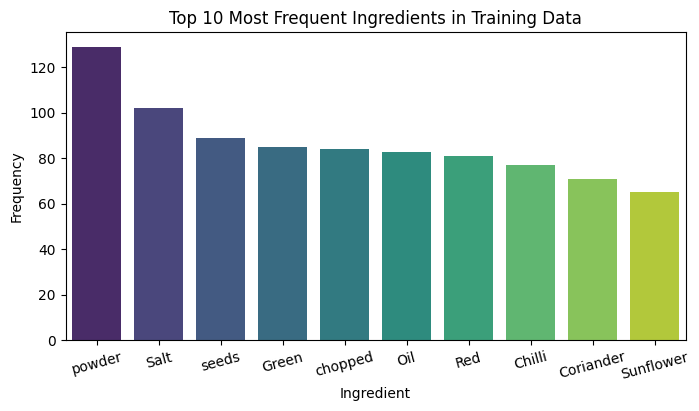

In [36]:
# plot the top frequent ingredients in training data
plot_top_items(get_top_frequent_items(ingredient_list, 'ingredient', 'Training'), 'ingredient', 'Training')


--- Top 10 units in Training


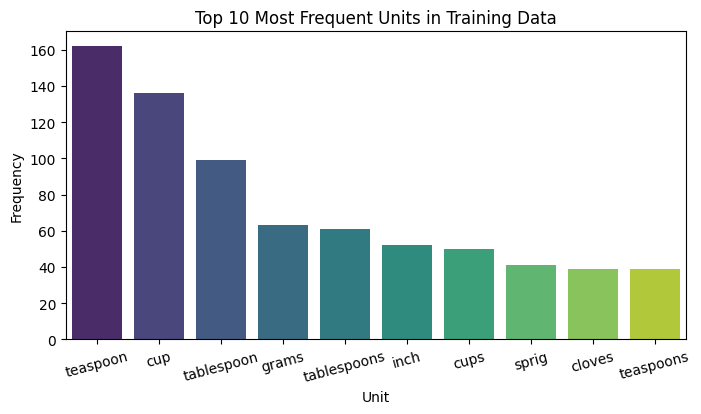

In [37]:
# plot the top frequent units in training data
plot_top_items(get_top_frequent_items(unit_list, 'unit', 'Training'), 'unit', 'Training')

## **5** Exploratory Recipe Data Analysis on Validation Dataset

#### **5.1** *Execute EDA on Validation Dataset with insights*
Initialise the dataset_name as ***Validation*** and call the ***plot_top_items*** for top 10 ingredients and units in the recipe data
Provide the insights for the same.



In [38]:
# initialise the dataset_name
dataset_name_val = 'Validation'

In [39]:
# use extract and validate tokens, categorise tokens, get top frequent items for ingredient list and unit list on validation dataframe
val_flat_input_tokens, val_flat_pos_tokens = extract_and_validate_tokens(val_df, dataset_name_val)

ingredient_list_val, unit_list_val, quantity_list_val = categorize_tokens(val_flat_input_tokens, val_flat_pos_tokens)


--- Validation Dataset Token Validation ---
Length of flattened input_tokens: 2876
Length of flattened pos_tokens: 2876

First 10 input_tokens for Validation:
['1', 'cup', 'Ada', '2', 'liter', 'Milk', '3/4', 'Sugar', 'tablespoon', 'Ghee']

First 10 pos_tokens for Validation:
['quantity', 'unit', 'ingredient', 'quantity', 'unit', 'ingredient', 'quantity', 'ingredient', 'unit', 'ingredient']



--- Top 10 ingredients in Validation


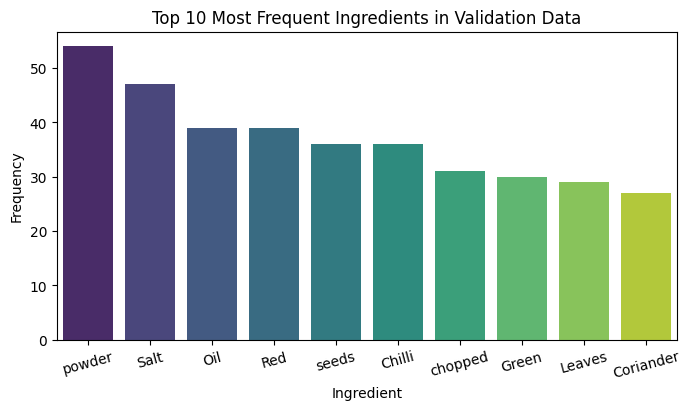

In [40]:
# plot the top frequent ingredients in validation data
plot_top_items(get_top_frequent_items(ingredient_list_val, 'ingredient', dataset_name_val), 'ingredient', dataset_name_val)


--- Top 10 units in Validation


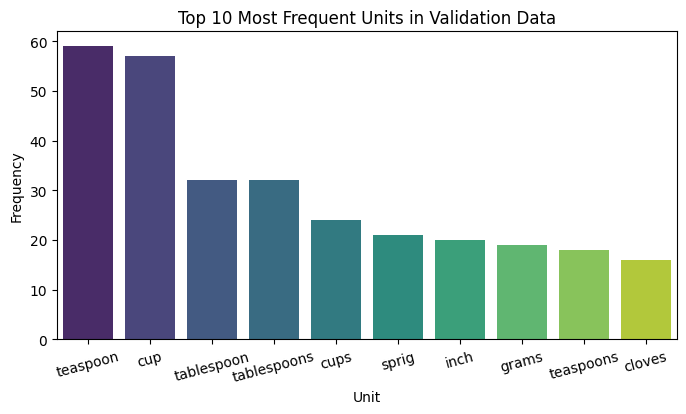

In [41]:
# plot the top frequent units in training data
plot_top_items(get_top_frequent_items(unit_list_val, 'unit', dataset_name_val), 'unit', dataset_name_val)

## **6** Feature Extraction For CRF Model 

### **6.1** *Define a feature functions to take each token from recipe*

Define a function as ***word2features*** which takes a particular recipe and its index to work with all recipe input tokens and include custom key-value pairs.

Also, use feature key-value pairs to mark the beginning and end of the sequence and to also check whether the word belongs to unit, quantity etc. Use keyword sets for unit and quantity for differentiating feature functions well. Also make use of relevant regex patterns on fractions, whole numbers etc.

##### **6.1.1** **Define keywords for unit and quantity and create a quantity pattern to work on fractions, numbers and decimals**

Create sets for **unit_keywords** and ***quantity_keywords*** and include all the words relevant for measuring the ingredients such as cup, tbsp, tsp etc. and in quantity keywords, include words such as half, quarter etc.

Also suggested to use regex pattern as ***quantity_pattern*** to work with quantity in any format such as fractions, numbers and decimals.

Then, load the spacy model and process the entire sentence

In [42]:
# define unit and quantity keywords along with quantity pattern
unit_keywords=set(unit_list)
quantity_keywords=set(quantity_list)
quantity_pattern = re.compile(
    r"""
    (?:(?:\d+\s+)?\d+/\d+)|     # Matches '1/2' or '1 1/2'
    \d+\.\d+|                   # Matches decimals like '1.5'
    \d+|                        # Matches whole numbers like '1'
    [¼½¾⅐⅑⅒⅓⅔⅕⅖⅗⅘⅙⅚⅛⅜⅝⅞]       # Matches unicode fractions
    """,
    re.VERBOSE
)

In [43]:
# load spaCy model
nlp=spacy.load("en_core_web_sm")

##### **6.1.2** **Define feature functions for CRF**

Define ***word2features*** function and use the parameters such as sentence and its indexing as ***sent*** and ***i*** for extracting token level features for CRF Training.
Build ***features*** dictionary, also mark the beginning and end of the sequence and use the ***unit_keywords***, ***quantity_keywords*** and ***quantity_pattern*** for knowing the presence of quantity or unit in the tokens

While building ***features*** dictionary, include
- ***Core Features*** - The core features of a token should capture its lexical
and grammatical properties. Include attributes like the raw token, its lemma, part-of-speech tag, dependency relation, and shape, as well as indicators for whether it's a stop word, digit, or punctuation. The details of the features are given below:

    - `bias` - Constant feature with a fixed value of 1.0 to aid model learning.
    - `token` - The lowercase form of the current token.
    - `lemma` - The lowercase lemma (base form) of the token.
    - `pos_tag` - Part-of-speech (POS) tag of the token.
    - `tag` - Detailed POS tag of the token.
    - `dep` - Dependency relation of the token in the sentence.
    - `shape` - Shape of the token (e.g., "Xxx" for "Milk").
    - `is_stop` - Boolean indicating if the token is a stopword.
    - `is_digit` - Boolean indicating if the token consists of only digits.
    - `has_digit` - Boolean indicating if the token contains at least one digit.
    - `has_alpha` - Boolean indicating if the token contains at least one alphabetic character.
    - `hyphenated` - Boolean indicating if the token contains a hyphen (-).
    - `slash_present` - Boolean indicating if the token contains a slash (/).
    - `is_title` - Boolean indicating if the token starts with an uppercase letter.
    - `is_upper` - Boolean indicating if the token is fully uppercase.
    - `is_punct` - Boolean indicating if the token is a punctuation mark.

- ***Improved Quantity and Unit Detection*** - Use key-value pairs to mark the presence of quantities and units in the features dictionary. Utilise the unit_keywords, quantity_keywords, and quantity_pattern to identify and flag these elements. The details of the features are given below:

    - `is_quantity` - Boolean indicating if the token matches a quantity pattern or keyword.
    - `is_unit` - Boolean indicating if the token is a known measurement unit.
    - `is_numeric` - Boolean indicating if the token matches a numeric pattern.
    - `is_fraction` - Boolean indicating if the token represents a fraction (e.g., 1/2).
    - `is_decimal` - Boolean indicating if the token represents a decimal number (e.g., 3.14).
    - `preceding_word` - The previous token in the sentence, if available.
    - `following_word` - The next token in the sentence, if available.

- ***Contextual Features*** - Incorporate contextual information by adding features for the preceding and following tokens. Include indicators like BOS and EOS to mark the beginning and end of the sequence, and utilise unit_keywords, quantity_keywords, and quantity_pattern to identify the types of neighboring tokens. The features are given below:

    - `prev_token` - The lowercase form of the previous token.
    - `prev_is_quantity` - Boolean indicating if the previous token is a quantity.
    - `prev_is_digit` - Boolean indicating if the previous token is a digit.
    - `BOS` - Boolean indicating if the token is at the beginning of the sentence.
    - `next_token` - The lowercase form of the next token.
    - `next_is_unit` - Boolean indicating if the next token is a unit.
    - `next_is_ingredient` - Boolean indicating if the next token is not a unit or quantity.
    - `EOS` - Boolean indicating if the token is at the end of the sentence.



In [44]:
# define word2features for processing each token in the sentence sent by using index i.
# use your own feature functions

    # Process the entire sentence with spaCy
def word2features(sent, i):
    token = sent[i]
    doc=nlp(token)
    token=doc[0]
    # --- Core Features ---
    features = {
        'bias': 1.0,
        'token': token.text.lower(),
        'lemma': token.lemma_.lower(),
        'pos_tag': token.pos_,
        'tag': token.tag_,
        'dep': token.dep_,
        'shape': token.shape_,
        'is_stop': token.is_stop,
        'is_digit': token.is_digit,
        'has_digit': any(char.isdigit() for char in token.text),
        'has_alpha': any(char.isalpha() for char in token.text),
        'hyphenated': '-' in token.text,
        'slash_present': '/' in token.text,
        'is_title': token.is_title,
        'is_upper': token.is_upper,
        'is_punct': token.is_punct,}

    # --- Improved Quantity & Unit Detection ---
    token_lc = token.text.lower()
    features['is_quantity'] = (bool(quantity_pattern.fullmatch(token_lc)) or token_lc in quantity_keywords)
    features['is_unit'] = token_lc in unit_keywords
    features['is_numeric'] = bool(re.fullmatch(r"\d+(\.\d+)?", token_lc))
    features['is_fraction'] = bool(re.fullmatch(r"\d+/\d+|[¼½¾⅓⅔⅛⅜⅝⅞]", token_lc))
    features['is_decimal'] = '.' in token_lc and token_lc.replace('.', '', 1).isdigit()
    features['preceding_word'] = sent[i - 1] if i > 0 else ''
    features['following_word'] = sent[i + 1] if i < len(sent) - 1 else ''

    # --- Contextual Features ---
    if i > 0:
        prev = nlp(sent[i - 1])[0]
        prev_token = sent[i - 1].lower()
        features['prev_token'] = prev_token
        features['prev_is_quantity'] = (bool(quantity_pattern.fullmatch(prev_token)) or prev_token in quantity_keywords)
        features['prev_is_digit'] = prev_token.isdigit()
    else:
        features['BOS'] = True
    if i < len(sent) - 1:
        next = nlp(sent[i + 1])[0]
        next_token = sent[i + 1].lower()
        features['next_token'] = next_token
        features['next_is_unit'] = next_token in unit_keywords
        features['next_is_ingredient'] = not (
            next_token in unit_keywords or
            next_token in quantity_keywords or
            bool(quantity_pattern.fullmatch(next_token))
        )
    else:
        features['EOS'] = True

    return features

### **6.2** *Preparation of Recipe level features*


##### **6.2.1** **Define function to work on all the recipes and call word2features for each recipe** 

Define ***sent2features*** function and inputs ***sent*** as a parameter and correctly generate feature functions for each token present in the sentence

In [45]:
# define sent2features by working on each token in the sentence and correctly generate dictionaries for features
def sent2features(sent):
  return [word2features(sent, i) for i in range(len(sent))]

### **6.3** *Convert X_train, X_val, y_train and y_val into train and validation feature sets and labels*



##### **6.3.1** **Convert recipe into feature functions by using X_train and X_val**

Create ***X_train_features*** and ***X_val_features*** as list to include the feature functions for each recipe present in training and validation sets

In [46]:
# Convert input sentences into feature sets by taking training and validation dataset as X_train_features and X_val_features
X_train_features = [sent2features(sent) for sent in X_train]
X_val_features = [sent2features(sent) for sent in X_val]

##### **6.3.2** **Convert lables of y_train and y_val into list**

Create ***y_train_labels*** and ***y_val_labels*** by using the list of y_train and y_val

In [47]:
# Convert labels into list as y_train_labels and y_val_labels
y_train_labels = list(y_train)
y_val_labels = list(y_val)

##### **6.3.3** **Print the length of val and train features and labels**

In [48]:
# print the length of train features and labels
print(len(X_train_features))
print(len(y_train_labels))

196
196


In [49]:
# print the length of validation features and labels
print(len(X_val_features))
print(len(y_val_labels))

84
84


### **6.4** *Applying weights to feature sets*




##### **6.4.1** **Flatten the labels of y_train**

Create ***y_train_flat*** to flatten the structure of nested y_train

In [50]:
# Flatten labels in y_train
y_train_flat = flatten_list(y_train_labels)

##### **6.4.2** **Count the labels present in training target dataset** 

Create ***label_counts*** to count the frequencies of labels present in y_train_flat and retrieve the total samples by using the values of label_counts as ***total_samples***

In [51]:
# Count label frequencies as label_counts and total_samples as getting the summation of values of label_counts
label_counts = Counter(y_train_flat)
total_samples = sum(label_counts.values())

for label, count in label_counts.items():
    print(f"Label: {label}, Count: {count}, Frequency: {count/total_samples:.4f}")

Label: quantity, Count: 980, Frequency: 0.1378
Label: unit, Count: 811, Frequency: 0.1140
Label: ingredient, Count: 5323, Frequency: 0.7482


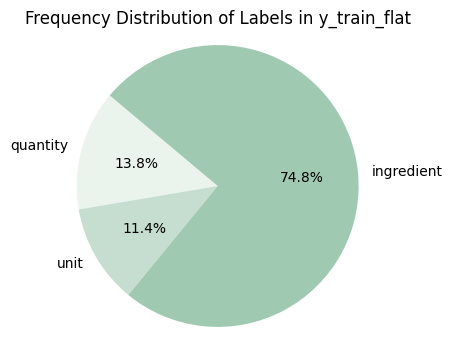

In [52]:
labels = list(label_counts.keys())
counts = list(label_counts.values())

plt.figure(figsize=(4, 4))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.light_palette('seagreen'))
plt.title('Frequency Distribution of Labels in y_train_flat')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

##### **6.4.3** **Compute weight_dict by using inverse frequency method for label weights**

- Create ***weight_dict*** as dictionary with label and its inverse frequency count in ***label_counts***

- Penalise ingredient label in the dictionary

In [53]:
# Compute class weights (inverse frequency method) by considering total_samples and label_counts
weight_dict={}
for label, count in label_counts.items():
    weight_dict[label]=total_samples/count
print("Class Weights (Inverse Frequency):", weight_dict)

Class Weights (Inverse Frequency): {'quantity': 7.259183673469388, 'unit': 8.771886559802713, 'ingredient': 1.336464399774563}


In [54]:
# penalise ingredient label
weight_dict['ingredient']=weight_dict['ingredient']/2
print("Adjusted Class Weights:", weight_dict)

Adjusted Class Weights: {'quantity': 7.259183673469388, 'unit': 8.771886559802713, 'ingredient': 0.6682321998872816}


##### **6.4.4** **Extract features along with class weights**

Define a function ***extract_features_with_class_weights*** to work with training and validation datasets and extract features by applying class weights





In [55]:
# Apply weights to feature extraction in extract_features_with_class_weights by using parameters such as X (input tokens), y(labels) and weight_dict (Class weights)
def extract_features_with_class_weights(X, y, weight_dict):
    X_weighted_features = []
    for sent, labels in zip(X, y):
        sent_features = []
        for i in range(len(sent)):
            features = word2features(sent, i)
            label = labels[i]
            # Apply class weight to the features
            features['class_weight'] = weight_dict.get(label, 1.0)
            sent_features.append(features)
        X_weighted_features.append(sent_features)
    return X_weighted_features

##### **6.4.5** **Execute extract_features_with_class_weights on training and validation datasets**

Create ***X_train_weighted_features*** and ***X_val_weighted_features*** for extracting training and validation features along with their weights by calling ***extract_features_with_class_weights*** on the datasets

In [56]:
# Apply manually computed class weights
X_train_weighted_features = extract_features_with_class_weights(X_train, y_train_labels, weight_dict)
X_val_weighted_features = extract_features_with_class_weights(X_val, y_val_labels, weight_dict)

## **7** Model Building and Training

### **7.1** *Initialise the CRF model and train it* 
Train the CRF model with the specified hyperparameters such as

### CRF Model Hyperparameters Explanation

| Parameter                  | Description |
|----------------------------|-------------|
| **algorithm='lbfgs'**      | Optimisation algorithm used for training. `lbfgs` (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is a quasi-Newton optimisation method. |
| **c1=0.5**                | L1 regularisation term to control sparsity in feature weights. Helps in feature selection. |
| **c2=1.0**                | L2 regularisation term to prevent overfitting by penalising large weights. |
| **max_iterations=100**     | Maximum number of iterations for model training. Higher values allow more convergence but increase computation time. |
| **all_possible_transitions=True** | Ensures that all possible state transitions are considered in training, making the model more robust. |

Use weight_dict for training CRF



In [57]:
# initialise CRF model with the specified hyperparameters and use weight_dict
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.5,
    c2=1.0,
    max_iterations=100,
    all_possible_transitions=True)

# train the CRF model with the weighted training data
crf.fit(X_train_weighted_features, y_train_labels)

,algorithm,'lbfgs'
,min_freq,None
,all_possible_states,None
,all_possible_transitions,True
,c1,0.5
,c2,1.0
,max_iterations,100
,num_memories,None
,epsilon,None
,period,None
,delta,None


### **7.2** *Evaluation of Training Dataset using CRF model*
Evaluate on training dataset using CRF by using flat classification report and confusion matrix

In [58]:
# evaluate on the training dataset
y_train_pred = crf.predict(X_train_weighted_features)

In [59]:
# specify the flat classification report by using training data for evaluation
print(flat_classification_report(y_train_labels, y_train_pred, digits=4))

              precision    recall  f1-score   support

  ingredient     1.0000    1.0000    1.0000      5323
    quantity     1.0000    0.9990    0.9995       980
        unit     0.9988    1.0000    0.9994       811

    accuracy                         0.9999      7114
   macro avg     0.9996    0.9997    0.9996      7114
weighted avg     0.9999    0.9999    0.9999      7114



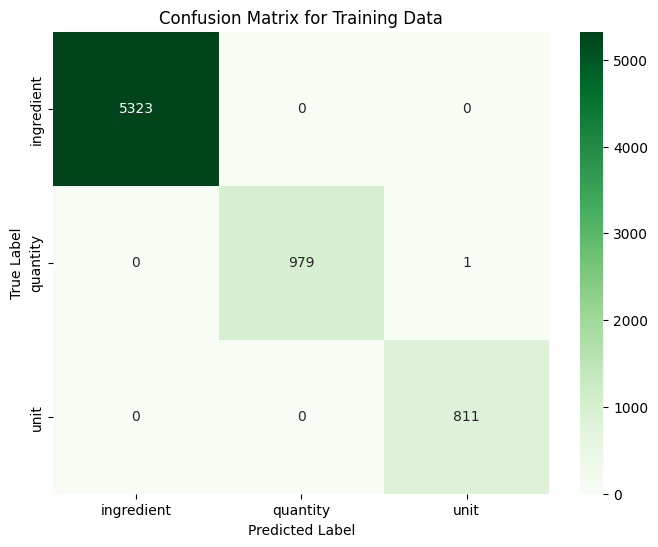

In [60]:
# create a confusion matrix on training datset

# Flatten the true and predicted labels for the confusion matrix
y_train_true_flat = [label for sent in y_train_labels for label in sent]
y_train_pred_flat = [label for sent in y_train_pred for label in sent]

# Define the labels for the confusion matrix
labels = sorted(list(set(y_train_true_flat)))

# Compute the confusion matrix
cm = confusion_matrix(y_train_true_flat, y_train_pred_flat, labels=labels)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Training Data')
plt.show()

### **7.3** *Save the CRF model*
Save the CRF model

In [61]:
# dump the model using joblib as crf_model.pkl
joblib.dump(crf, 'crf_model.pkl')

['crf_model.pkl']

## **8** Prediction and Model Evaluation

### **8.1** *Predict and Evaluate the CRF model on validation set* 
Evaluate the metrics for CRF model by using flat classification report and confusion matrix




In [62]:
# predict the crf model on validation dataset
y_val_pred = crf.predict(X_val_weighted_features)

In [63]:
# specify flat classification report
print(flat_classification_report(y_val, y_val_pred, digits=4))

              precision    recall  f1-score   support

  ingredient     1.0000    1.0000    1.0000      2107
    quantity     0.9951    0.9903    0.9927       411
        unit     0.9889    0.9944    0.9916       358

    accuracy                         0.9979      2876
   macro avg     0.9947    0.9949    0.9948      2876
weighted avg     0.9979    0.9979    0.9979      2876



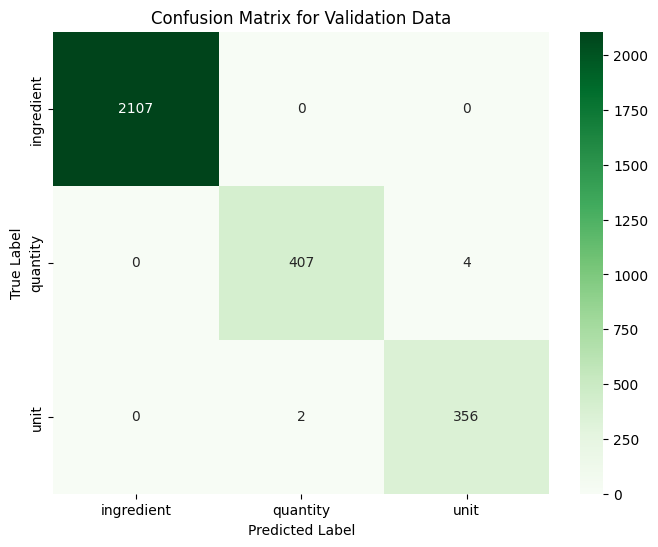

In [64]:
# create a confusion matrix on validation dataset

# Flatten the true and predicted labels for the confusion matrix
y_val_true_flat = [label for sent in y_val_labels for label in sent]
y_val_pred_flat = [label for sent in y_val_pred for label in sent]

# Define the labels for the confusion matrix
labels = sorted(list(set(y_val_true_flat)))

# Compute the confusion matrix
cm_val = confusion_matrix(y_val_true_flat, y_val_pred_flat, labels=labels)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Validation Data')
plt.show()

## **9** Error Analysis on Validation Data
Investigate misclassified samples in validation dataset and provide the insights


### **9.1** *Investigate misclassified samples in validation dataset*



##### **9.1.1** Flatten the labels of validation data and initialise error data



Flatten the true and predicted labels and initialise the error data as ***error_data***

In [65]:
# flatten Labels and Initialise Error Data
flat_y_val = flatten_list(y_val_labels)
flat_y_val_pred = flatten_list(y_val_pred)

##### **9.1.2** Iterate the validation data and collect Error Information



Iterate through validation data (X_val, y_val_labels, y_pred_val) and compare true vs. predicted labels. Collect error details, including surrounding context, previous/next tokens, and class weights, then store them in error_data

In [66]:
# Iterate and collect Error Information
error_data = []
for i in range(len(X_val)): # Iterate through each recipe in the validation set
    sent_tokens = X_val[i] # Get the list of input tokens for the current recipe
    true_labels = y_val_labels[i] # Get the list of true POS labels for the current recipe
    predicted_labels = y_val_pred[i] # Get the list of predicted POS labels for the current recipe

    for j in range(len(sent_tokens)): # Iterate through each token in the current recipe
        token = sent_tokens[j]
        true_label = true_labels[j]
        predicted_label = predicted_labels[j]

        if true_label != predicted_label: # Check for misclassification
            # Get previous and next tokens with handling for boundary cases
            previous_token = sent_tokens[j-1] if j > 0 else None
            next_token = sent_tokens[j+1] if j < len(sent_tokens) - 1 else None

            # Determine the class weight for the true label
            weight = weight_dict.get(true_label, 1.0) # Default to 1.0 if label not in weight_dict

            # Collect context around the error (e.g., 3 tokens before and after)
            context_start = max(0, j - 3)
            context_end = min(len(sent_tokens), j + 4)
            context_tokens = sent_tokens[context_start:context_end]
            context = ' '.join(context_tokens)

            error_data.append({
                'token': token,
                'previous_token': previous_token,
                'next_token': next_token,
                'true_label': true_label,
                'predicted_label': predicted_label,
                'weight': weight,
                'context': context
            })

##### **9.1.3** Create dataframe from error_data and print overall accuracy 



Change error_data into dataframe and then use it to illustrate the overall accuracy of validation data

In [67]:
# Create DataFrame and Print Overall Accuracy
error_df = pd.DataFrame(error_data)

# Calculate overall accuracy for validation data
overall_accuracy = metrics.flat_accuracy_score(y_val_labels, y_val_pred)

print(f"Overall Accuracy on Validation Data: {overall_accuracy:.2%}")

Overall Accuracy on Validation Data: 99.79%


##### **9.1.4** Analyse errors by label type
Analyse errors found in the validation data by each label and display their class weights along with accuracy and also display the error dataframe with token,  previous token, next token, true label, predicted label and context

In [68]:
# Analyse errors found in the validation data by each label
# and display their class weights along with accuracy
# and display the error dataframe with token, previous token, next token, true label, predicted label and context

error_summary = error_df['true_label'].value_counts().reset_index()
error_summary.columns = ['Label', 'Error_Count']
error_summary['Total_Count'] = error_summary['Label'].map(label_counts)
error_summary['Error_Rate'] = error_summary['Error_Count'] / error_summary['Total_Count']
print("Error Summary by Label:")
display(error_summary)

# and display the error dataframe with token, previous token, next token, true label, predicted label and context
print(f"Detailed Misclassifications")
display(error_df)

Error Summary by Label:


,Label,Error_Count,Total_Count,Error_Rate
0,quantity,4,980,0.004082
1,unit,2,811,0.002466


Detailed Misclassifications


,token,previous_token,next_token,true_label,predicted_label,weight,context
0,is,Pur,2,quantity,unit,7.259184,18 Pani Pur is 2 Potato Aloo
1,for,Oil,kneading,quantity,unit,7.259184,pinch Sunflower Oil for kneading 4 Potatoes
2,to,10,12,unit,quantity,8.771887,diced small 10 to 12 Green beans
3,a,Haldi,pinch,unit,quantity,8.771887,Turmeric powder Haldi a pinch Asafoetida hing
4,pinch,Dal,Asafoetida,quantity,unit,7.259184,White Urad Dal pinch Asafoetida hing sprig
5,cloves,Tomatoes,Garlic,quantity,unit,7.259184,Asafoetida Onion Tomatoes cloves Garlic Ginger Turmeric


### **9.2** *Provide insights from the validation dataset*




<font color="green">The validation results show strong performance, with very low error rates for both labels (unit ≈ 0.24%, quantity ≈ 0.4%). The few errors observed are systematic rather than random.

### <font color="green">Key insights from the detailed misclassifications:

#### <font color="green">- Context-driven confusion:
Tokens such as “to” and “a” are sometimes misclassified as quantity when they appear near numbers (e.g., “10 to 12”, “Haldi a pinch”), due to their proximity to numeric expressions.

#### <font color="green">- Ambiguity in culinary measures:
Words like “is”, “for”, “pinch” and “cloves” are occasionally predicted as unit instead of quantity. These act as implicit quantities in recipe text, leading to overlap between the two classes.

#### <font color="green">- Neighbouring ingredient influence:
Some errors occur when adjacent tokens are ingredient names (e.g., “Haldi pinch”, “cloves Garlic”), showing that local context can bias predictions.

#### <font color="green">- Overall conclusion:
With only 6 misclassified tokens in the validation set, the model generalises well. Remaining errors stem from linguistic edge cases, suggesting that phrase-level handling of numeric ranges and implicit quantities could further improve accuracy.

## **10** Conclusion

Write your findings and conclusion.

#### <font color="green">1. Data Preparation
- The recipe data, provided in JSON format, was loaded into a Pandas DataFrame. Each entry contained an input string (raw ingredient list) and pos (corresponding NER labels).
- Initial data inspection revealed 285 entries with two columns. A crucial step involved tokenizing the input and pos strings into **input_tokens** and **pos_tokens** respectively.
- Data validation identified 5 rows with inconsistent lengths between **input_tokens** and **pos_tokens**. These problematic rows were dropped to ensure data integrity, resulting in a clean dataset of 280 entries.
- The dataset was then split into training (70%) and validation (30%) sets, resulting in 196 training samples and 84 validation samples.

#### <font color="green">2. Exploratory Data Analysis (EDA)
- EDA was performed on the training dataset to understand the distribution of labels and frequently occurring tokens.
- Unique POS labels were confirmed to be 'quantity', 'unit', and 'ingredient'.
- Flattening the token lists allowed for frequency analysis: 'ingredient' was the most frequent label (74.8%), followed by 'quantity' (13.8%) and 'unit' (11.4%).
- Top 10 frequent ingredients included **'powder', 'Salt', 'seeds', and 'Oil'. Top 10 frequent units included 'teaspoon', 'cup', 'tablespoon', and 'grams'**.

#### <font color="green">3. Feature Engineering for CRF Model
- A word2features function was developed to extract a rich set of token-level features, including core lexical and grammatical properties (token, lemma, POS tags, shape, etc.), and contextual features (previous/next tokens, BOS/EOS).
- Enhanced features for quantity and unit detection were integrated using unit_keywords, quantity_keywords, and a quantity_pattern regex to identify numerical, fractional, and decimal quantities.
- The sent2features function applied word2features to all tokens in a sentence, converting raw text into a format suitable for CRF training.
- Class weights were computed using an inverse frequency method and applied to the features. The 'ingredient' label was penalized (weight divided by 2) to give relatively more importance to 'quantity' and 'unit' during training.

#### <font color="green">4. Model Training and Evaluation
- A sklearn_crfsuite CRF model was initialized with hyperparameters: algorithm='lbfgs', c1=0.5, c2=1.0, max_iterations=100, and all_possible_transitions=True.
- The model was trained using the weighted training features (X_train_weighted_features) and corresponding labels (y_train_labels).
- **Training Performance:** The model achieved exceptionally high scores on the training data:
  - **Precision, Recall, F1-score:** All were near 1.00 for 'ingredient', 'quantity', and 'unit'.
  - **Accuracy:** 0.9999.
  - The confusion matrix showed almost perfect classification.
- **Validation Performance:** The model's generalization capability was assessed on the validation set:
  - **Precision, Recall, F1-score:** High scores (0.99-1.00) across all labels.
  - **Accuracy:** 0.9979.
  - The confusion matrix indicated strong performance with very few misclassifications.

#### 5. <font color="green">Error Analysis on Validation Data
- An in-depth error analysis was conducted on the validation set, which showed an overall accuracy of 99.79%.
- **Label-Specific Errors:**
  - **Quantity:** 4 misclassifications out of 411 instances (Error Rate: 0.004082)
  - **Unit:** 2 misclassifications out of 358 instances (Error Rate: 0.002466)
- **Key Insights from Detailed Misclassifications:**
  - **Context-driven confusion:** Tokens like “to” and “a” were sometimes misclassified as 'quantity' when appearing near numbers (e.g., “10 to 12”), due to proximity to numeric expressions.
  - **Ambiguity in culinary measures:** Words like “is”, “for”, “pinch” and “cloves” were occasionally predicted as 'unit' instead of 'quantity'. These act as implicit quantities, leading to overlap between classes.
  - **Neighboring ingredient influence:** Some errors occurred when adjacent tokens were ingredient names (e.g., “Haldi pinch”, “cloves Garlic”), indicating local context could bias predictions.

#### <font color="green">Conclusion

**Model Strengths:** The CRF model demonstrates strong performance in extracting ingredients, quantities, and units from recipe text, achieving high accuracy on both training and validation sets. Its ability to leverage sequence-based features and contextual information is evident in its robust performance.

**Model Weaknesses & Areas for Improvement:** While overall performance is excellent, the minor misclassifications highlight linguistic edge cases and potential ambiguities. The model occasionally confuses words that can function as implicit quantities or units, or where their classification is highly context-dependent.

With only 6 misclassified tokens in the validation set, the current model generalizes very well. Addressing these remaining edge cases through improved data consistency and subtle feature engineering can lead to an even more robust and accurate NER system for recipe data.